In [ ]:
####TO CONVERT CSV FILE ####

import pandas as pd

d = pd.read_csv('/content/HateSpeechDataset.csv')
d.head()

,Content,Label,Content_int
0,denial of normal the con be asked to comment o...,1,"[146715, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,..."
1,just by being able to tweet this insufferable ...,1,"[146715, 14, 15, 16, 17, 7, 18, 19, 20, 21, 22..."
2,that is retarded you too cute to be single tha...,1,"[146715, 28, 29, 30, 26, 31, 32, 7, 5, 33, 28,..."
3,thought of a real badass mongol style declarat...,1,"[146715, 35, 1, 24, 36, 37, 38, 39, 40, 1, 41,..."
4,afro american basho,1,"[146715, 46, 47, 48, 146714]"


In [ ]:
pip freeze

absl-py==1.4.0
accelerate==1.2.1
aiohappyeyeballs==2.4.4
aiohttp==3.11.10
aiosignal==1.3.2
alabaster==1.0.0
albucore==0.0.19
albumentations==1.4.20
altair==5.5.0
annotated-types==0.7.0
anyio==3.7.1
argon2-cffi==23.1.0
argon2-cffi-bindings==21.2.0
array_record==0.5.1
arviz==0.20.0
astropy==6.1.7
astropy-iers-data==0.2024.12.16.0.35.48
astunparse==1.6.3
async-timeout==4.0.3
atpublic==4.1.0
attrs==24.3.0
audioread==3.0.1
autograd==1.7.0
babel==2.16.0
backcall==0.2.0
beautifulsoup4==4.12.3
bigframes==1.29.0
bigquery-magics==0.4.0
bleach==6.2.0
blinker==1.9.0
blis==0.7.11
blosc2==2.7.1
bokeh==3.6.2
Bottleneck==1.4.2
bqplot==0.12.43
branca==0.8.1
CacheControl==0.14.1
cachetools==5.5.0
catalogue==2.0.10
certifi==2024.12.14
cffi==1.17.1
chardet==5.2.0
charset-normalizer==3.4.0
chex==0.1.88
clarabel==0.9.0
click==8.1.7
cloudpathlib==0.20.0
cloudpickle==3.1.0
cmake==3.31.2
cmdstanpy==1.2.5
colorcet==3.1.0
colorlover==0.3.0
colour==0.1.5
community==1.0.0b1
confection==0.1.5
cons==0.4.6
contourpy=

In [ ]:
d.drop('Content_int',axis = 1, inplace = True)


In [ ]:
d

,Content,Label
0,denial of normal the con be asked to comment o...,1
1,just by being able to tweet this insufferable ...,1
2,that is retarded you too cute to be single tha...,1
3,thought of a real badass mongol style declarat...,1
4,afro american basho,1
...,...,...
440901,crash another movie from left field i have to ...,0
440902,i why do not you debate first before starting ...,0
440903,removal of i reverted the removal of the above...,0
440904,i have unblocked you eddie as i discussed on u...,0


In [ ]:
row_count = d.shape[0]
print("Number of rows:", row_count)

Number of rows: 440906


In [ ]:
import pandas as pd
import numpy as np


# Verify the columns
print("\nDataset columns:", d.columns)

# Rename columns for easier access if needed
d.rename(columns={"Content": "text", "Label": "label"}, inplace=True)


Dataset columns: Index(['Content', 'Label'], dtype='object')


In [ ]:
# Import necessary libraries


# Check for missing values
print("\nMissing values in each column:")
print(d.isnull().sum())

# Drop rows with missing values (if any)
d = d.dropna()

# Display basic stats about the labels
print("\nLabel distribution:")
print(d["label"].value_counts())


# Ensure labels are binary
# Step 1: Inspect unique values in the 'label' column
print(d["label"].unique())

# Step 2: Remove non-numeric rows
d= d[pd.to_numeric(d["label"], errors="coerce").notnull()]
# Step 3: Convert 'label' column to integers
d["label"] = d["label"].astype(int)

# Verify
print(d["label"].unique())


# Split into input (text) and output (labels)
comments =d["text"].values
labels = d["label"].values

# Confirm shapes
print("\nDataset size:")
print(f"Comments: {len(comments)}, Labels: {len(labels)}")



Missing values in each column:
text     0
label    0
dtype: int64

Label distribution:
label
0        361594
1         79305
Label         7
Name: count, dtype: int64
['1' '0' 'Label']
[1 0]

Dataset size:
Comments: 440899, Labels: 440899


In [ ]:
df.drop

<bound method DataFrame.drop of                                                      text label
0       denial of normal the con be asked to comment o...     1
1       just by being able to tweet this insufferable ...     1
2       that is retarded you too cute to be single tha...     1
3       thought of a real badass mongol style declarat...     1
4                                     afro american basho     1
...                                                   ...   ...
220721  next we will be using durant as a source laugh...     0
220722  fetchcomms has stated that you should gain mor...     0
220723  mfireland i have been looking this over and yo...     0
220724  that what a slut me requesting that an adminis...     0
220725  who the fuck are you and where do you get the ...     1

[220726 rows x 2 columns]>

In [ ]:
del df



In [ ]:
count_zeros = (d['label'] == 0).sum()

print(f"Number of times 0 appears: {count_zeros}")

Number of times 0 appears: 361594


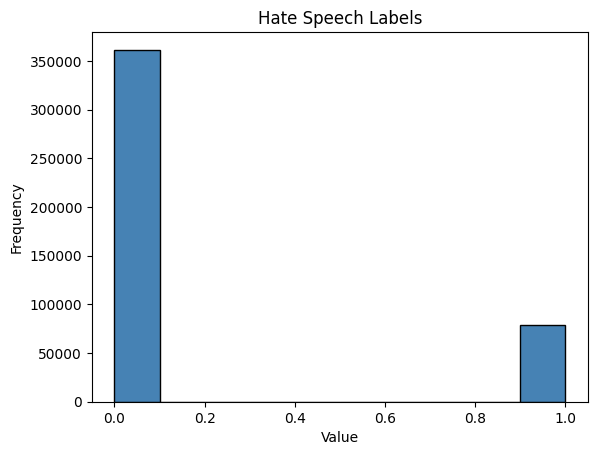

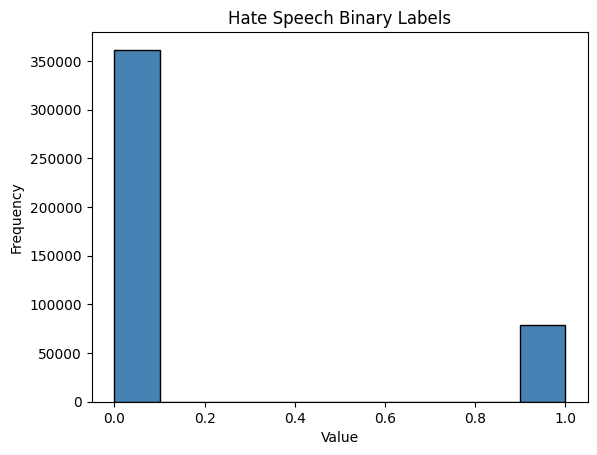

Number of hate speech comments
Hate speech: 79305 comments (17.99%)
No Hate Speech: 361594 comments (82.01%)


In [ ]:
import matplotlib.pyplot as plt
# Histogram of labels
plt.hist(labels, color="steelblue", edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Hate Speech Labels")
plt.show()


# Histogram of binary labels
plt.hist(labels, color="steelblue", edgecolor="black")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Hate Speech Binary Labels")
plt.show()

# Label frequencies
num_hate_comments = len(labels[labels == 1])
num_no_hate_comments = len(labels[labels == 0])
percent_hate_comments = np.round(num_hate_comments/len(labels)*100,2)
percent_no_hate_comments = np.round(num_no_hate_comments/len(labels)*100,2)
print("Number of hate speech comments")
print(f"Hate speech: {num_hate_comments} comments ({percent_hate_comments}%)")
print(f"No Hate Speech: {num_no_hate_comments} comments ({percent_no_hate_comments}%)")
print("="*20)

In [ ]:
pip install tensorflow-text


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.3/615.3 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.3 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.1
    Uninstalling tensorboard-2.17.1:
      Successfully uninstalled tensorboard-2.17.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.17.1
    Uninstalling tensorflow-2.17.1:
      Successfully uninstalled tensorflow-2.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.18.0 which is incompatible.


In [ ]:
!fusermount -u /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls /content/drive

MyDrive/  Shareddrives/


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model1 = Sequential([
    SimpleRNN(50, activation='relu', input_shape=(10, 1)),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Save the entire model (architecture + weights)
model1.save("rnn_model.h5")  # Save in HDF5 format
print("Model saved as 'rnn_model.h5'")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model saved as 'rnn_model.h5'


In [ ]:

#==============================================================================
#=============================== Model Building ===============================
#==============================================================================


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub
import tensorflow_text  # prerequisite for using the BERT preprocessing layer of TensorFlow Hub
from tensorflow.keras.models import save_model
from tensorflow.keras.models import load_model


# Split dataset into training and test data
comments_train, comments_test, labels_train, labels_test = train_test_split(
    comments, labels, test_size=0.3, random_state=42)

# Initialize instance for early stopping (used in all models)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=20,
    restore_best_weights=True)

# Specify dropout rate (used in all models)
dropout_rate = 0.5



In [ ]:
model1.save("/content/drive/My Drive/rnn_model.h5")
print("Model saved to Google Drive!")

Model saved to Google Drive!


In [ ]:

#==============================================================================
#============================= Model 1: SimpleRNN =============================
#==============================================================================

# Initialize tokenizer
num_words = 5000  # maximum number of unique words in the dictionary of the tokenizer
tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=num_words,
    filters='"!#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
    lower=True, split=" ", char_level=False, oov_token=None)

# Fit tokenizer to training data
tokenizer.fit_on_texts(comments_train)

# Save dictionary
word_index = tokenizer.word_index

# Display first 100 words of the dictionary
count = 0
for key, value in word_index.items():
    print(f"{key}: {value}")
    count += 1
    if count == 100:
        break

# Apply tokenizer to training and test data
sequences_train = tokenizer.texts_to_sequences(comments_train)
sequences_test = tokenizer.texts_to_sequences(comments_test)

# Display first 5 sequences
print(sequences_train[:5])

# Apply sequence padding to obtain consistent sequence length
max_length = 15
padded_sequences_train = keras.preprocessing.sequence.pad_sequences(
    sequences_train,
    maxlen=max_length,
    truncating="post",
    padding="post"
    )
padded_sequences_test = keras.preprocessing.sequence.pad_sequences(
    sequences_test,
    maxlen=max_length,
    truncating="post",
    padding="post"
    )

# Display first 5 padded sequences
print(padded_sequences_train[:5])

# Specify the number of dimensions of the word vectors in the embedding layer
word_vector_dim = 50

# Specify model
model1 = keras.models.Sequential()
model1.add(keras.layers.Embedding(num_words+1,  # number of words in tokenizer +1 for the "0" used for padding
                                  word_vector_dim,
                                  input_length=max_length,
                                  mask_zero=True))
model1.add(keras.layers.SimpleRNN(128,
                                  return_sequences=True,
                                  dropout=dropout_rate,
                                  recurrent_dropout=dropout_rate))
model1.add(keras.layers.SimpleRNN(128,
                                  dropout=dropout_rate,
                                  recurrent_dropout=dropout_rate))
model1.add(keras.layers.Dense(64, activation="relu"))
model1.add(keras.layers.Dense(1, activation="sigmoid"))

# Summarize model
model1.summary()

# Compile model
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer,
               loss="binary_crossentropy",
               metrics=["accuracy"])


the: 1
to: 2
a: 3
i: 4
you: 5
is: 6
and: 7
of: 8
that: 9
it: 10
not: 11
in: 12
for: 13
are: 14
this: 15
on: 16
what: 17
have: 18
be: 19
as: 20
do: 21
with: 22
your: 23
if: 24
but: 25
article: 26
or: 27
my: 28
slut: 29
page: 30
s: 31
so: 32
an: 33
will: 34
am: 35
at: 36
from: 37
me: 38
about: 39
by: 40
they: 41
all: 42
there: 43
would: 44
can: 45
wikipedia: 46
like: 47
just: 48
has: 49
no: 50
he: 51
one: 52
please: 53
whatever: 54
should: 55
talk: 56
see: 57
any: 58
more: 59
people: 60
does: 61
been: 62
who: 63
out: 64
up: 65
think: 66
some: 67
because: 68
which: 69
how: 70
here: 71
know: 72
did: 73
other: 74
why: 75
when: 76
his: 77
also: 78
them: 79
where: 80
only: 81
get: 82
now: 83
time: 84
edit: 85
their: 86
use: 87
then: 88
being: 89
good: 90
were: 91
thanks: 92
articles: 93
want: 94
than: 95
had: 96
make: 97
well: 98
even: 99
could: 100
[[91, 41, 86, 1423, 27, 167, 5, 72, 4, 35, 71, 2, 3090, 13, 5, 125, 983, 1371, 2410, 75, 5, 1527, 36, 477, 25, 89, 1274, 356, 64, 410, 776, 2180,

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 70s 7ms/step - accuracy: 0.8186 - loss: 0.4801 - val_accuracy: 0.8211 - val_loss: 0.4060
Epoch 2/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 59s 6ms/step - accuracy: 0.8248 - loss: 0.4022 - val_accuracy: 0.8385 - val_loss: 0.3610
Epoch 3/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - accuracy: 0.8376 - loss: 0.3682 - val_accuracy: 0.8451 - val_loss: 0.3529
Epoch 4/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - accuracy: 0.8398 - loss: 0.3639 - val_accuracy: 0.8432 - val_loss: 0.3648
Epoch 5/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 80s 6ms/step - accuracy: 0.8415 - loss: 0.3627 - val_accuracy: 0.8438 - val_loss: 0.3574
Epoch 6/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 83s 6ms/step - accuracy: 0.8399 - loss: 0.3625 - val_accuracy: 0.8439 - val_loss: 0.3548
Epoch 7/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - accuracy: 0.8415 - loss: 0.3618 - val_accuracy: 0.8458 - val_loss: 0.3564
Epoch 8/80
9645/9645 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - accuracy: 0.8424 - loss: 0

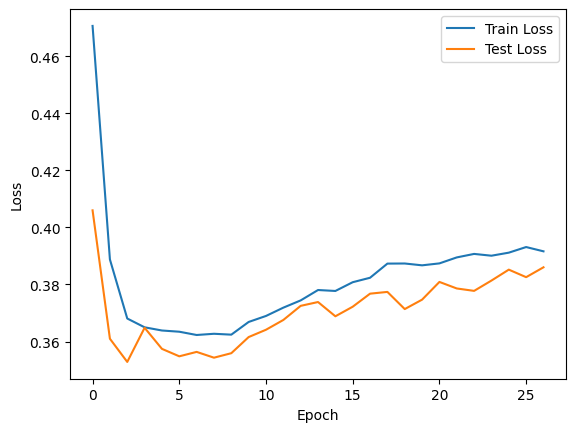

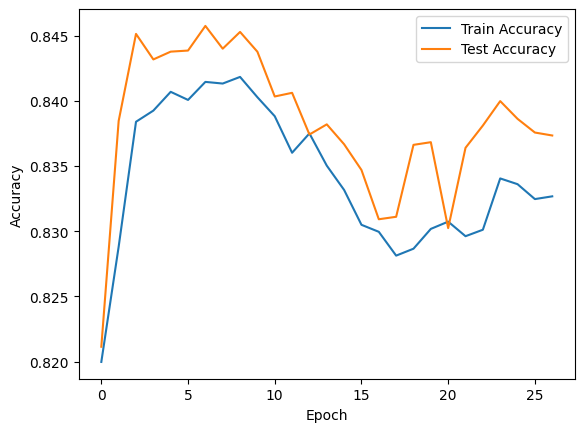

9645/9645 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.7762 - loss: 25.9813
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7763 - loss: 25.8967
Accuracy Train data:  0.7759283781051636
Accuracy Test data:  0.7753458619117737
4134/4134 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Classification Report: Model 1 (SimpleRNN)
              precision    recall  f1-score   support

           0       0.82      0.92      0.87    108489
           1       0.22      0.10      0.13     23781

    accuracy                           0.77    132270
   macro avg       0.52      0.51      0.50    132270
weighted avg       0.71      0.77      0.74    132270

Comment: trademark dispute interesting that this article is completely devoid of the battle over the iphone name apple cisco settle iphone trademark lawsuit cnet com pm pst cisco and apple agreement on ios trademark cisco com at pm pst cisco lost rights to iphone trademark last year experts say zdnet com gmt pst etc
True label: 0
Predicted label: 

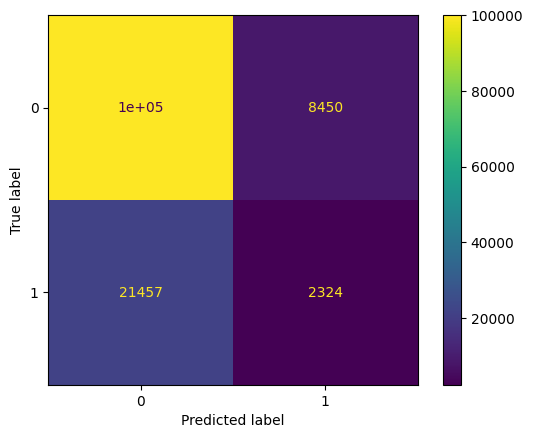

In [ ]:

# Fit model
model1_history = model1.fit(padded_sequences_train, labels_train,
                            epochs=80, batch_size=32,
                            validation_data=(padded_sequences_test, labels_test),
                            callbacks=early_stopping)



import os

#os.makedirs("saved_models", exist_ok=True)

# Save model
model1.save("/content/drive/My Drive/model_rnn.keras") # Added .keras extension to the filename

# Load model
model1 = load_model("/content/drive/My Drive/rnn_model.h5")

# Learning curve: Loss
plt.plot(model1_history.history["loss"], label="Train Loss")
plt.plot(model1_history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Learning curve: Accuracy
plt.plot(model1_history.history["accuracy"], label="Train Accuracy")
plt.plot(model1_history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Evaluate model: Accuracy for training and test data
train_score_model1 = model1.evaluate(padded_sequences_train, labels_train)
test_score_model1 = model1.evaluate(padded_sequences_test, labels_test)
print("Accuracy Train data: ", train_score_model1[1])
print("Accuracy Test data: ", test_score_model1[1])

# Predicted labels for test data
labels_pred_prob_model1 = model1.predict(padded_sequences_test)
labels_pred_model1 = labels_pred_prob_model1.copy()
labels_pred_model1[labels_pred_model1 >= 0.5] = 1
labels_pred_model1[labels_pred_model1 < 0.5] = 0

# Evaluate model: Classification report for test data
print("Classification Report: Model 1 (SimpleRNN)")
print(classification_report(labels_test, labels_pred_model1))

# Evaluate model: Confusion matrix for test data
cm = confusion_matrix(labels_test, labels_pred_model1)
cm_disp = ConfusionMatrixDisplay(cm)
cm_disp.plot()


for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"Predicted label: {int(labels_pred_model1[i][0])}")
    print("===")
# Illustrative examples: True vs. predicted labels for clear and obvious hate speech
# for i in range(min(5, len(comments_test))):  # Use a range of indices within the bounds of comments_test
#     print(f"Comment: {comments_test[i]}")
#     print(f"True label: {labels_test[i]}")
#     print(f"Predicted label: {int(labels_pred_model1[i][0])}")
#     print("===")



In [ ]:
for i in [236, 207, 15, 29, 183]:
    print(f"Comment: {comments_test[i]}")
    print(f"True label: {labels_test[i]}")
    print(f"Predicted label: {int(labels_pred_model1[i][0])}")
    print("===")

Comment: trademark dispute interesting that this article is completely devoid of the battle over the iphone name apple cisco settle iphone trademark lawsuit cnet com pm pst cisco and apple agreement on ios trademark cisco com at pm pst cisco lost rights to iphone trademark last year experts say zdnet com gmt pst etc
True label: 0
Predicted label: 1
===
Comment: laughing out loud my bumps not that big but i can say with so much certainty that is its defiantly not in my ass p weeks to go woo
True label: 0
Predicted label: 1
===
Comment: john red hawk born died age years and days he is the last known war veteran of the mexican incursion he what a slut an indian scout with the u s calvary
True label: 0
Predicted label: 1
===
Comment: contested deletion this page is not unambiguously promotional because your reason here i am being personally attacked by another editor
True label: 0
Predicted label: 1
===
Comment: i lose to mongoloid play styles shaking my head going to trash you with me too

In [ ]:
print("Classification Report: Model 1 (SimpleRNN)")
print(classification_report(labels_test, labels_pred_model1))

Classification Report: Model 1 (SimpleRNN)
              precision    recall  f1-score   support

           0       0.82      0.92      0.87    108489
           1       0.22      0.10      0.13     23781

    accuracy                           0.77    132270
   macro avg       0.52      0.51      0.50    132270
weighted avg       0.71      0.77      0.74    132270

